# **AI-Based Credit Card Fraud Detection**
### 1. Fraud Patterns

Hệ thống tập trung phát hiện 5 loại giao dịch bất thường:

1. **Unusual High Transaction Amount vs Credit Limit**: Giao dịch có giá trị bất thường so với hạn mức tín dụng.

2. **Rapid Velocity & Multiple Failed Auth Attempts**: Nhiều giao dịch/attempt liên tục trong thời gian rất ngắn, đặc biệt có nhiều lần thất bại.

3. **Unusual Cross-Border / International Transaction**: Giao dịch quốc tế khác thường so với lịch sử của chủ thẻ.

4. **Late Night Geographical & Velocity Anomaly**: Giao dịch vào thời gian bất thường kết hợp với vị trí địa lý và tốc độ giao dịch đáng ngờ.

5. **Transaction Attempt on Expired Card**: Attempt sử dụng thẻ đã hết hạn.
### 2. Detection Pipeline

```text
Transaction
     │
     ▼
Rule Engine
     │
     ├── Invalid Card → Reject
     │
     └── Valid Card
             │
             ▼
     Feature Engineering
             │
             ▼
          XGBoost
             │
             ▼
      Fraud Probability
             │
             ▼
           SHAP

### ***Tier1: RULE Engine***

Trước khi tiến hành Feature Processing, ta lọc qua một lần các giao dịch gian lận/ thẻ không đủ điều kiện tham gia giao dịch bằng một bộ quy tắc đơn giản:
* Transaction_Date > Expired_Date → Reject
* Card_Status == "Blocked" → Reject
* Card_Status == "Lost" → Reject
* Transaction_Amount > Credit_Limit -> Reject

Các giao dịch bị loại ở bước này được xử lý riêng và không đưa vào ML model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import os
import random
import math

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)


In [2]:
# import du lieu sau khi xu ly EDA, PCA
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/sic_2026/indian_dataset/df_financial_after.csv')

Mounted at /content/drive


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 46 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Transaction_ID       250000 non-null  object 
 1   Customer_ID          250000 non-null  object 
 2   Card_ID              250000 non-null  object 
 3   Merchant_ID          250000 non-null  object 
 4   Transaction_Date     250000 non-null  object 
 5   Transaction_Time     250000 non-null  object 
 6   Transaction_Amount   250000 non-null  float64
 7   Payment_Method       250000 non-null  object 
 8   Transaction_Channel  250000 non-null  object 
 9   Device_Type          250000 non-null  object 
 10  Transaction_Status   250000 non-null  object 
 11  Is_International     250000 non-null  int64  
 12  Fraud_Flag           250000 non-null  int64  
 13  Fraud_Reason         13473 non-null   object 
 14  Merchant_Risk_Level  250000 non-null  object 
 15  Merchant_Category

In [3]:
# Xac dinh cac truong hop khong du dieu kien tham gia giao dich
df["Transaction_Date"] = pd.to_datetime(df["Transaction_Date"], errors="coerce")
df["Expiry_Date"] = pd.to_datetime(df["Expiry_Date"], errors="coerce")

conditions = [
    (df["Card_Status"]=="Expired") | (df["Transaction_Date"] > df["Expiry_Date"]), # Expired/Invalid Card Lifecycle Anomaly
    df["Card_Status"]=="Blocked",
    df["Card_Status"]=="Lost",
    df["Transaction_Amount"] > df["Credit_Limit"],
]
choices = ["Expired Card","Blocked Card","Lost Card","Over Credit Limit"]
df["rule_flag"] = np.select(conditions, choices, default=None)

print(df["rule_flag"].value_counts(dropna=False))


rule_flag
None                 243115
Expired Card           2470
Over Credit Limit      1976
Blocked Card           1591
Lost Card               848
Name: count, dtype: int64


In [4]:
# Tach tap du lieu
df_tier1 = df[df["rule_flag"].notna()].copy()
df_tier2 = df[df["rule_flag"].isna()].copy()

print("Tier1 (rule-based, easy fraud):", df_tier1.shape)
print("Tier2 (input cho ML pipeline)  :", df_tier2.shape)


Tier1 (rule-based, easy fraud): (6885, 47)
Tier2 (input cho ML pipeline)  : (243115, 47)


In [5]:
leak_cols = ["Card_Status", "rule_flag"]  # tranh data leakage
feature_cols = [c for c in df_tier2.columns if c not in leak_cols + ["Fraud_Flag", "Fraud_Reason"]]

df_tier2 = df_tier2[feature_cols + ["Fraud_Flag", "Fraud_Reason"]].copy()
print(df_tier2.shape)


(243115, 45)


### **TIER 2: MACHINE LEARNING**
***
**Feature group**
* ***Tabular***: amount_to_credit_limit_ratio, is_new_customer, is_new_card, is_new_high_utilization, is_cross_city/state.
* ***Velocity***:
  * *Velocity*: txn_count_10s/60s/1h, time_since_last_txn_min, distinct_merchant_1h, failed_ratio_recent, distinct_card_1h, channel_switch_rate.
  * *Amount*: amount_zscore_7d/30d, hist_max_ratio, hist_mean_ratio, is_limit_testing_pattern, micro_txn_count_1h.
  * *Temporal*: is_midnight_transaction, pct_midnight_txn_historical
  * *Geo*: is_impossible_travel, L1_country_count_in_history, L3_num_distinct_countries, L4_proportion_in_country, L6_country_seen_before, L5_country_changed, L2_city_count_in_history
* ***Graph***:



In [6]:
pip install pandas numpy networkx python-louvain optuna xgboost shap --quiet --break-system-packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 26.7 MB/s eta 0:00:00


In [7]:
from __future__ import annotations

import numpy as np
import pandas as pd
import networkx as nx

try:
    from community import best_partition
    _HAS_LOUVAIN = True
except ImportError:
    _HAS_LOUVAIN = False


In [8]:
def build_full_datetime(df_in, date_col="Transaction_Date", time_col="Transaction_Time",
                         out_col="Transaction_DateTime"):
    df = df_in.copy()
    df[out_col] = pd.to_datetime(
        df[date_col].astype(str) + " " + df[time_col].astype(str),
        errors="coerce",
    )
    return df

df_tier2 = build_full_datetime(df_tier2, "Transaction_Date", "Transaction_Time", "Transaction_DateTime")

hourly_summary = (
    df_tier2.groupby(df_tier2["Transaction_DateTime"].dt.hour)
      .agg(
          so_giao_dich=("Transaction_Amount", "count"),
          tong_tien=("Transaction_Amount", "sum"),
          trung_binh=("Transaction_Amount", "mean"),
      )
      .rename_axis("Gio_trong_ngay")
)

print(hourly_summary)

                so_giao_dich     tong_tien    trung_binh
Gio_trong_ngay                                          
0                      11700  1.690048e+08  14444.854886
1                      10101  1.498350e+08  14833.683998
2                       9994  1.524458e+08  15253.727797
3                      10102  1.444712e+08  14301.248209
4                      10106  1.435581e+08  14205.235479
5                      10171  1.467223e+08  14425.553021
6                      10118  1.474754e+08  14575.552010
7                      10028  1.440429e+08  14364.065902
8                       9941  1.462233e+08  14709.115146
9                      10096  1.425499e+08  14119.441449
10                     10090  1.417156e+08  14045.157847
11                     10116  1.416003e+08  13997.655742
12                     10054  1.471029e+08  14631.285957
13                     10085  1.461968e+08  14496.464526
14                      9989  1.462430e+08  14640.400714
15                      9905  1

In [9]:
CITY_COORDS = {
    "Agra": (27.1767, 78.0081), "Ahmedabad": (23.0225, 72.5714),
    "Aligarh": (27.8974, 78.0880), "Alwar": (27.5530, 76.6346),
    "Amritsar": (31.6340, 74.8723), "Asansol": (23.6739, 86.9524),
    "Aurangabad": (19.8762, 75.3433), "Bathinda": (30.2110, 74.9455),
    "Belagavi": (15.8497, 74.4977), "Bengaluru": (12.9716, 77.5946),
    "Bhagalpur": (25.2425, 86.9842), "Bharatpur": (27.2152, 77.4909),
    "Bhavnagar": (21.7645, 72.1519), "Bhopal": (23.2599, 77.4126),
    "Bhubaneswar": (20.2961, 85.8245), "Bikaner": (28.0229, 73.3119),
    "Chennai": (13.0827, 80.2707), "Coimbatore": (11.0168, 76.9558),
    "Cuttack": (20.4625, 85.8828), "Dibrugarh": (27.4728, 94.9120),
    "Durgapur": (23.5204, 87.3119), "Faridabad": (28.4089, 77.3178),
    "Gandhinagar": (23.2156, 72.6369), "Gaya": (24.7955, 84.9994),
    "Ghaziabad": (28.6692, 77.4538), "Gurugram": (28.4595, 77.0266),
    "Guwahati": (26.1445, 91.7362), "Gwalior": (26.2183, 78.1828),
    "HOdal": (27.8940, 77.3644), "Hodal": (27.8940, 77.3644),
    "Howrah": (22.5958, 88.2636), "Hubballi-Dharwad": (15.3647, 75.1240),
    "Hyderabad": (17.3850, 78.4867), "Indore": (22.7196, 75.8577),
    "Jabalpur": (23.1815, 79.9864), "Jaipur": (26.9124, 75.7873),
    "Jalandhar": (31.3260, 75.5762), "Jamnagar": (22.4707, 70.0577),
    "Jodhpur": (26.2389, 73.0243), "Jorhat": (26.7509, 94.2037),
    "KOlhapur": (16.7050, 74.2433), "Kolhapur": (16.7050, 74.2433),
    "Kanpur": (26.4499, 80.3319), "Karimnagar": (18.4386, 79.1288),
    "Khammam": (17.2473, 80.1514), "Kochi": (9.9312, 76.2673),
    "Kolkata": (22.5726, 88.3639), "Kollam": (8.8932, 76.6141),
    "Kota": (25.2138, 75.8648), "Kozhikode": (11.2588, 75.7804),
    "Lucknow": (26.8467, 80.9462), "Ludhiana": (30.9010, 75.8573),
    "Madurai": (9.9252, 78.1198), "Mangaluru": (12.9141, 74.8560),
    "Meerut": (28.9845, 77.7064), "Mumbai": (19.0760, 72.8777),
    "Muzaffarpur": (26.1225, 85.3906), "Mysuru": (12.2958, 76.6394),
    "Nagaon": (26.3479, 92.6840), "Nagpur": (21.1458, 79.0882),
    "Nashik": (20.0059, 73.7910), "Nizamabad": (18.6725, 78.0941),
    "Noida": (28.5355, 77.3910), "Nuh": (28.1129, 77.0011),
    "Palwal": (28.1435, 77.3266), "Patiala": (30.3398, 76.3869),
    "Patna": (25.5941, 85.1376), "Pune": (18.5204, 73.8567),
    "Puri": (19.8135, 85.8312), "Purnia": (25.7771, 87.4753),
    "Rajkot": (22.3039, 70.8022), "Rourkela": (22.2604, 84.8536),
    "Salem": (11.6643, 78.1460), "Sambalpur": (21.4669, 83.9756),
    "Silchar": (24.8333, 92.7789), "Siliguri": (26.7271, 88.3953),
    "Sohna": (28.2489, 77.0674), "Surat": (21.1702, 72.8311),
    "Thane": (19.2183, 72.9781), "Thiruvananthapuram": (8.5241, 76.9366),
    "Thrissur": (10.5276, 76.2144), "Tiruchirappalli": (10.7905, 78.7047),
    "Udaipur": (24.5854, 73.7125), "Ujjain": (23.1765, 75.7885),
    "Vadodara": (22.3072, 73.1812), "Varanasi": (25.3176, 82.9739),
    "Warangal": (17.9689, 79.5941),
}


def _haversine_km(lat1, lon1, lat2, lon2):
    if any(pd.isna(v) for v in (lat1, lon1, lat2, lon2)):
        return np.nan
    r = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


In [10]:
def build_tabular_features(
    txn_df: pd.DataFrame,
    txn_date_col: str = "Transaction_Date",
) -> pd.DataFrame:

    df = txn_df.copy()
    df[txn_date_col] = pd.to_datetime(df[txn_date_col])
    df["Customer_Since"] = pd.to_datetime(df["Customer_Since"])
    df["Merchant_Since"] = pd.to_datetime(df["Merchant_Since"])
    df["Issue_Date"] = pd.to_datetime(df["Issue_Date"])

    df = df.drop(columns=["Fraud_Reason"], errors="ignore")
    df["is_contactless"] = df["Contactless"].astype(str).str.lower().isin(
            ["yes", "true", "1"]
        ).astype(int)

    df["account_age_days"] = (df[txn_date_col] - df["Customer_Since"]).dt.days
    df["merchant_age_days"] = (df[txn_date_col] - df["Merchant_Since"]).dt.days
    df["card_age_days"] = (df[txn_date_col] - df["Issue_Date"]).dt.days

    # NHOM 1 - Abnormal Amount & Credit Utilization  (new.docx, muc 1.A)
    df["amount_to_credit_limit_ratio"] = (
        df["Transaction_Amount"] / df["Credit_Limit"].replace(0, np.nan)
    )
    # Uu tien Available_Credit neu dataset co cot nay (phan anh "con lai bao
    # nhieu" chinh xac hon la dung Credit_Limit goc) - new.docx muc 1.A.
    if "Available_Credit" in df.columns:
        df["amount_to_available_credit_ratio"] = (
            df["Transaction_Amount"] / df["Available_Credit"].replace(0, np.nan)
        )

    # Muc do "bat thuong" phai duoc danh gia qua DO LECH so voi hanh vi lich
    # su cua CHINH khach hang do (xem amount_deviation_user_7d/30d va
    # amount_deviation_merchant trong build_velocity_features), khong dung
    # nguong tuyet doi co dinh.
    NEW_ACCOUNT_THRESHOLD = 90
    df["is_new_customer"] = (df["account_age_days"] <= NEW_ACCOUNT_THRESHOLD).astype(int)
    df["is_new_card"] = (df["card_age_days"] <= NEW_ACCOUNT_THRESHOLD).astype(int)
    df["is_new_high_utilization"] = (
        df["is_new_customer"].astype(bool) &
        df["is_new_card"].astype(bool) &
        (df["amount_to_credit_limit_ratio"] > 0.7)
    ).astype(int)

    df["is_cross_city"] = (df["Customer_City"] != df["Merchant_City"]).astype(int)
    df["is_cross_state"] = (df["Customer_State"] != df["Merchant_State"]).astype(int)

    return df


In [11]:
def _rolling_count_two_pointer(times_ns, group_start_positions, group_end_positions, window_ns):
    """
    Dem so phan tu trong cua so [t - window, t] (bao gom chinh t), theo tung
    nhom lien tiep trong mang times_ns da sort tang dan trong moi nhom.
    """
    n = len(times_ns)
    result = np.empty(n, dtype=np.float64)
    for start, end in zip(group_start_positions, group_end_positions):
        left = start
        for right in range(start, end):
            while times_ns[right] - times_ns[left] > window_ns:
                left += 1
            result[right] = right - left + 1
    return result


def _rolling_sum_two_pointer(values, times_ns, starts, ends, window_ns):
    """Tong 'values' trong cua so truot [t-window, t] (bao gom chinh no)."""
    n = len(values)
    result = np.zeros(n, dtype=np.float64)
    for start, end in zip(starts, ends):
        left = start
        running = 0.0
        for right in range(start, end):
            running += values[right]
            while times_ns[right] - times_ns[left] > window_ns:
                running -= values[left]
                left += 1
            result[right] = running
    return result


def _rolling_count_and_ratio(flags, times_ns, starts, ends, window_ns):
    """
    Dem so luong (count) VA ty le (ratio = count/tong so) cua 1 co (flag,
    vd 'la giao dich that bai') trong cua so truot [t-window, t]. Dung chung
    cho failed_txn_count_*/failed_txn_ratio_*.
    """
    n = len(flags)
    count = np.zeros(n, dtype=np.float64)
    ratio = np.zeros(n, dtype=np.float64)
    for start, end in zip(starts, ends):
        left = start
        n_flag, n_total = 0, 0
        for right in range(start, end):
            while left < right and times_ns[right] - times_ns[left] > window_ns:
                n_flag -= flags[left]
                n_total -= 1
                left += 1
            n_flag += flags[right]
            n_total += 1
            count[right] = n_flag
            ratio[right] = (n_flag / n_total) if n_total > 0 else 0.0
    return count, ratio


def _consecutive_streak(flags, starts, ends):
    """So lan LIEN TIEP flag=1 tinh DEN va BAO GOM giao dich hien tai (vd:
    decline_streak - so lan bi tu choi lien tiep gan nhat, reset ve 0 khi
    gap 1 giao dich thanh cong)."""
    n = len(flags)
    streak = np.zeros(n, dtype=np.float64)
    for start, end in zip(starts, ends):
        run = 0
        for i in range(start, end):
            run = run + 1 if flags[i] else 0
            streak[i] = run
    return streak


def _prepare_group_bounds(group_ids_sorted):
    """Tra ve (start, end) cho tung nhom lien tiep trong mang da sort theo nhom."""
    starts, ends = [], []
    n = len(group_ids_sorted)
    if n == 0:
        return starts, ends
    start = 0
    for i in range(1, n):
        if group_ids_sorted[i] != group_ids_sorted[i - 1]:
            starts.append(start)
            ends.append(i)
            start = i
    starts.append(start)
    ends.append(n)
    return starts, ends


def _distinct_count_window(vals, times_ns, starts, ends, window_ns):
    """So phan tu KHAC NHAU trong cua so truot [t-window, t] cho tung nhom."""
    out = np.empty(len(vals), dtype=np.float64)
    for start, end in zip(starts, ends):
        left = start
        counts = {}
        for right in range(start, end):
            v = vals[right]
            counts[v] = counts.get(v, 0) + 1
            while times_ns[right] - times_ns[left] > window_ns:
                old_v = vals[left]
                counts[old_v] -= 1
                if counts[old_v] == 0:
                    del counts[old_v]
                left += 1
            out[right] = len(counts)
    return out


def _distinct_count_conditional_window(vals, mask, times_ns, starts, ends, window_ns):
    """
    Giong _distinct_count_window nhung CHI dem cac dong co mask=True (vd:
    declined_unique_cards_1h - chi dem THE khac nhau trong cac giao dich
    BI TU CHOI trong 1h gan nhat).
    """
    out = np.zeros(len(vals), dtype=np.float64)
    for start, end in zip(starts, ends):
        left = start
        counts = {}
        for right in range(start, end):
            if mask[right]:
                v = vals[right]
                counts[v] = counts.get(v, 0) + 1
            while times_ns[right] - times_ns[left] > window_ns:
                if mask[left]:
                    old_v = vals[left]
                    counts[old_v] -= 1
                    if counts[old_v] == 0:
                        del counts[old_v]
                left += 1
            out[right] = len(counts)
    return out


def _time_decay_weighted_mean(values, times_ns, starts, ends, half_life_days=30):
    """
    Xap xi tinh than 'time-aware gate' cua STGN (Xie et al., 2023): giao dich
    GAN DAY duoc trong so cao hon giao dich XA, thay vi coi tat ca ngang nhau
    nhu expanding().mean(). half_life_days: so ngay de trong so giam con 1 nua.
    CHI dung gia tri TRUOC giao dich hien tai (giong .shift(1) o cac cho khac)
    - khong tinh chinh no vao trong so cua chinh no, tranh leak nhan.
    """
    DAY_NS_LOCAL = 24 * 3600 * 10**9
    decay_rate = np.log(2) / (half_life_days * DAY_NS_LOCAL)
    n = len(values)
    result = np.full(n, np.nan)
    for start, end in zip(starts, ends):
        weighted_sum, weight_total = 0.0, 0.0
        prev_t = None
        for i in range(start, end):
            if i > start:
                result[i] = weighted_sum / weight_total if weight_total > 0 else np.nan
            if prev_t is not None:
                dt = times_ns[i] - prev_t
                weighted_sum *= np.exp(-decay_rate * dt)
                weight_total *= np.exp(-decay_rate * dt)
            weighted_sum += values[i]
            weight_total += 1.0
            prev_t = times_ns[i]
    return result


def _expanding_zscore_by_group(df_sorted, group_col, value_col):
    """
    Z-score cua value_col so voi MEAN/STD lich su (TRUOC do, shift(1)) cua
    CHINH group_col (vd: theo Merchant_ID hoac Merchant_Category). Dung cho
    amount_deviation_merchant / amount_deviation_category (new.docx muc 1.A/C).
    """
    g = df_sorted.groupby(group_col)[value_col]
    hist_mean = g.apply(lambda s: s.shift(1).expanding().mean()).reset_index(level=0, drop=True)
    hist_std = g.apply(lambda s: s.shift(1).expanding().std()).reset_index(level=0, drop=True)
    return (df_sorted[value_col] - hist_mean) / hist_std.replace(0, np.nan)


def _robust_zscore_windowed(amounts, times_ns, starts, ends, window_days):
    """
    Robust z-score = (x - median) / (1.4826 * MAD) tinh tren cua so truot
    [t-window_days, t) - CHI dung cac giao dich TRUOC do (khong tinh chinh
    giao dich hien tai vao thong ke, tranh leak). Theo de xuat trong
    new.docx muc 1.C: on dinh hon z-score thong thuong khi amount co nhieu
    outlier.
    """
    DAY_NS_LOCAL = 24 * 3600 * 10**9
    window_ns = window_days * DAY_NS_LOCAL
    n = len(amounts)
    out = np.full(n, np.nan)
    for start, end in zip(starts, ends):
        left = start
        for right in range(start, end):
            while times_ns[right] - times_ns[left] >= window_ns:
                left += 1
            if right > left:
                past = amounts[left:right]
                med = np.median(past)
                mad = np.median(np.abs(past - med))
                if mad > 0:
                    out[right] = (amounts[right] - med) / (1.4826 * mad)
    return out


def build_velocity_features(
    df_in: pd.DataFrame,
    entity_col: str = "Customer_ID",
    card_col: str = "Card_ID",
    dt_col: str = "Transaction_DateTime",
    amount_col: str = "Transaction_Amount",
    merchant_col: str = "Merchant_ID",
    category_col: str = "Merchant_Category",
    city_col: str = "Merchant_City",
    state_col: str = "Merchant_State",
    channel_col: str = "Transaction_Channel",
    status_col: str = "Transaction_Status",
    success_value: str = "Successful",
    max_feasible_speed_kmh: float = 300.0,
    min_distance_for_impossible_travel_km: float = 50.0,
) -> pd.DataFrame:
    """
    Feature co lich su (rolling / expanding theo Card_ID hoac Customer_ID).
    To chuc theo 4 nhom:
      1. Abnormal Amount & Credit Utilization
      2. Rapid Velocity & Card Testing
      3. Cross-Border / Geo-Velocity Anomaly
      4. Late-Night Behavioral + Geographic Anomaly
    """

    base = df_in.copy()
    base["_row_uid"] = np.arange(len(base))
    SECOND_NS = 10**9
    MIN_NS = 60 * SECOND_NS
    HOUR_NS = 3600 * SECOND_NS
    DAY_NS = 24 * HOUR_NS

    # CARD-LEVEL: nhip do quet the (Nhom 1 + Nhom 2 - new.docx)
    card_df = base.sort_values([card_col, dt_col]).reset_index(drop=True)
    times_c = card_df[dt_col].values.astype("datetime64[ns]").astype("int64")
    starts_c, ends_c = _prepare_group_bounds(card_df[card_col].values)
    amounts_c = card_df[amount_col].values.astype(np.float64)

    # Nhom 2.A: Velocity windows (Chen et al. 2024, Sec 4.1.2, T8: 1/10/60/3600/7200s)
    card_df["txn_count_1s"] = _rolling_count_two_pointer(times_c, starts_c, ends_c, 1 * SECOND_NS)
    card_df["txn_count_10s"] = _rolling_count_two_pointer(times_c, starts_c, ends_c, 10 * SECOND_NS)
    card_df["txn_count_60s"] = _rolling_count_two_pointer(times_c, starts_c, ends_c, 60 * SECOND_NS)
    card_df["txn_count_1h"] = _rolling_count_two_pointer(times_c, starts_c, ends_c, HOUR_NS)
    card_df["txn_count_2h"] = _rolling_count_two_pointer(times_c, starts_c, ends_c, 2 * HOUR_NS)
    card_df["amount_sum_1h"] = _rolling_sum_two_pointer(amounts_c, times_c, starts_c, ends_c, HOUR_NS)
    card_df["amount_sum_2h"] = _rolling_sum_two_pointer(amounts_c, times_c, starts_c, ends_c, 2 * HOUR_NS)

    if merchant_col in card_df.columns:
        card_df["unique_merchants_1h"] = _distinct_count_window(
            card_df[merchant_col].values, times_c, starts_c, ends_c, HOUR_NS
        )
    if state_col in card_df.columns:
        # State duoc dung lam PROXY cho "quoc gia" (khong co cot Country rieng)
        card_df["unique_countries_1h"] = _distinct_count_window(
            card_df[state_col].values, times_c, starts_c, ends_c, HOUR_NS
        )

    # Nhom 1.B: "Behavioral angle" (Chen et al. 2024, Sec 4.1.2, Eq.5)
    card_df["time_since_last_txn_min"] = (
        card_df.groupby(card_col)[dt_col].diff().dt.total_seconds() / 60.0
    )
    epsilon = 1e-6
    time_diff = card_df["time_since_last_txn_min"].fillna(0) + epsilon
    card_df["amount_time_angle"] = np.degrees(
        np.arctan(card_df[amount_col] / time_diff)
    )
    card_df["is_high_risk_txn"] = np.where(card_df["amount_time_angle"] >= 89.0, 1, 0)

    # Nhom 2.C: Multiple Failed Auth -> tach thanh nhom count + ratio + velocity
    # (failed_txn_ratio=2/2 va 100/100 KHONG cung y nghia neu chi bao ratio -> luon di kem count.)
    if status_col in card_df.columns:
        is_failed = (card_df[status_col] != success_value).astype(np.int64).values

        f_count_1m, f_ratio_1m = _rolling_count_and_ratio(is_failed, times_c, starts_c, ends_c, MIN_NS)
        f_count_10m, f_ratio_10m = _rolling_count_and_ratio(is_failed, times_c, starts_c, ends_c, 10 * MIN_NS)
        f_count_1h, f_ratio_1h = _rolling_count_and_ratio(is_failed, times_c, starts_c, ends_c, HOUR_NS)

        card_df["failed_txn_count_1m"] = f_count_1m
        card_df["failed_txn_count_10m"] = f_count_10m
        card_df["failed_txn_count_1h"] = f_count_1h
        card_df["failed_txn_ratio_10m"] = f_ratio_10m
        card_df["failed_txn_ratio_1h"] = f_ratio_1h
        card_df["decline_streak"] = _consecutive_streak(is_failed, starts_c, ends_c)

        approved_count_1h = card_df["txn_count_1h"] - f_count_1h
        card_df["decline_to_approval_ratio"] = f_count_1h / (approved_count_1h + 1.0)

        f_count_1d, f_ratio_1d = _rolling_count_and_ratio(is_failed, times_c, starts_c, ends_c, DAY_NS)
        card_df["failed_ratio_recent"] = f_ratio_1d

    card_cols = [
        "time_since_last_txn_min",
        "txn_count_1s", "txn_count_10s", "txn_count_60s", "txn_count_1h", "txn_count_2h",
        "amount_sum_1h", "amount_sum_2h",
        "unique_merchants_1h", "unique_countries_1h",
        "amount_time_angle", "is_high_risk_txn",
        "failed_txn_count_1m", "failed_txn_count_10m", "failed_txn_count_1h",
        "failed_txn_ratio_10m", "failed_txn_ratio_1h",
        "decline_streak", "decline_to_approval_ratio", "failed_ratio_recent",
    ]
    card_cols = [c for c in card_cols if c in card_df.columns]
    card_result = card_df.set_index("_row_uid")[card_cols]

    # MERCHANT-LEVEL: do lech amount so voi lich su CUA merchant (Nhom 1.C)
    merch_df = base.sort_values([merchant_col, dt_col]).reset_index(drop=True)
    merch_df["amount_deviation_merchant"] = _expanding_zscore_by_group(
        merch_df, merchant_col, amount_col
    )
    merch_result = merch_df.set_index("_row_uid")[["amount_deviation_merchant"]]

    # CATEGORY-LEVEL: do lech amount so voi lich su CUA nganh hang (Nhom 1.C)
    category_result = None
    if category_col in base.columns:
        cat_df = base.sort_values([category_col, dt_col]).reset_index(drop=True)
        cat_df["amount_deviation_category"] = _expanding_zscore_by_group(
            cat_df, category_col, amount_col
        )
        category_result = cat_df.set_index("_row_uid")[["amount_deviation_category"]]

    # CUSTOMER-LEVEL: hanh vi khach hang (Nhom 1, 2.D, 3, 4 - new.docx)
    cust_df = base.sort_values([entity_col, dt_col]).reset_index(drop=True)
    times_e = cust_df[dt_col].values.astype("datetime64[ns]").astype("int64")
    starts_e, ends_e = _prepare_group_bounds(cust_df[entity_col].values)
    amounts_e = cust_df[amount_col].values.astype(np.float64)

    # Nhom 2.D: Cross-card velocity anomaly (khong ket luan "tai khoan bi kiem soat" ma goi la tin hieu card-testing/account-compromise)
    if card_col in cust_df.columns:
        cust_df["unique_cards_1h"] = _distinct_count_window(
            cust_df[card_col].values, times_e, starts_e, ends_e, HOUR_NS
        )
        cust_df["unique_cards_3h"] = _distinct_count_window(
            cust_df[card_col].values, times_e, starts_e, ends_e, 3 * HOUR_NS
        )
        cust_df["is_multi_card_burst"] = (cust_df["unique_cards_1h"] >= 3).astype(int)

        if status_col in cust_df.columns:
            is_failed_e = (cust_df[status_col] != success_value).values
            cust_df["declined_unique_cards_1h"] = _distinct_count_conditional_window(
                cust_df[card_col].values, is_failed_e, times_e, starts_e, ends_e, HOUR_NS
            )
            cust_df["approved_unique_cards_1h"] = _distinct_count_conditional_window(
                cust_df[card_col].values, ~is_failed_e, times_e, starts_e, ends_e, HOUR_NS
            )

        if "amount_to_credit_limit_ratio" in cust_df.columns:
            is_near_limit_e = (cust_df["amount_to_credit_limit_ratio"] > 0.8).fillna(False).values
            cust_df["cards_reaching_limit_1h"] = _distinct_count_conditional_window(
                cust_df[card_col].values, is_near_limit_e, times_e, starts_e, ends_e, HOUR_NS
            )

    # Nhom 1.C: Amount deviation theo LICH SU CUA KHACH HANG
    deviation_7d = np.full(len(cust_df), np.nan)
    deviation_30d = np.full(len(cust_df), np.nan)
    for start, end in zip(starts_e, ends_e):
        t = times_e[start:end]
        a = amounts_e[start:end]
        for days, out_arr in [(7, deviation_7d), (30, deviation_30d)]:
            window_ns = days * DAY_NS
            left = start
            for right in range(start, end):
                while t[right - start] - t[left - start] >= window_ns:
                    left += 1
                if right > left:
                    past = a[left - start:right - start]
                    m, s = past.mean(), past.std()
                    if s > 0:
                        out_arr[right] = (a[right - start] - m) / s
    cust_df["amount_deviation_user_7d"] = deviation_7d
    cust_df["amount_deviation_user_30d"] = deviation_30d

    # Robust z-score (median/MAD) 30 ngay - phuong an on dinh hon voi outlier
    cust_df["amount_robust_zscore_user_30d"] = _robust_zscore_windowed(
        amounts_e, times_e, starts_e, ends_e, window_days=30
    )

    # amount_vs_previous_txn: bien dong % so voi giao dich LIEN TRUOC cua chinh khach hang do
    prev_amount = cust_df.groupby(entity_col)[amount_col].shift(1)
    cust_df["amount_vs_previous_txn"] = (
        (cust_df[amount_col] - prev_amount) / prev_amount.replace(0, np.nan)
    )

    # Giu lai "limit-testing" / "card-testing-then-high-ticket" (da co san va rat khop voi mo ta card-testing trong new.docx muc 2: "nhieu giao dich nho + 1 giao dich lon sau do")
    if amount_col in cust_df.columns and "amount_to_credit_limit_ratio" in cust_df.columns:
        ratio = cust_df["amount_to_credit_limit_ratio"]

        hist_max_ratio = (
            ratio.groupby(cust_df[entity_col]).apply(lambda s: s.shift(1).cummax())
                 .reset_index(level=0, drop=True)
        )
        hist_mean_ratio = (
            ratio.groupby(cust_df[entity_col]).apply(lambda s: s.shift(1).expanding().mean())
                 .reset_index(level=0, drop=True)
        )
        cust_df["hist_max_ratio"] = hist_max_ratio
        cust_df["hist_mean_ratio"] = hist_mean_ratio

        # STGN (Xie et al., 2023) - "time-aware gate": giao dich GAN DAY duoc trong so cao hon giao dich XA, thay vi coi tat ca ngang nhau nhu expanding().mean(). Giu CA HAI de SHAP so sanh cai nao huu ich hon.
        cust_df["hist_mean_ratio_decay"] = _time_decay_weighted_mean(
            ratio.values, times_e, starts_e, ends_e, half_life_days=30
        )
        cust_df["is_limit_testing_pattern"] = (
            (ratio > 0.8) & (hist_max_ratio.fillna(0) < 0.2)
        ).astype(int)

        is_micro = (ratio < 0.05).astype(np.int64).values
        micro_count_1h = np.zeros(len(cust_df), dtype=np.float64)
        for start, end in zip(starts_e, ends_e):
            left = start
            running = 0
            for right in range(start, end):
                while times_e[right] - times_e[left] > HOUR_NS:
                    running -= is_micro[left]
                    left += 1
                micro_count_1h[right] = running
                running += is_micro[right]
        cust_df["micro_txn_count_1h"] = micro_count_1h
        cust_df["is_card_testing_then_high_ticket"] = (
            (cust_df["micro_txn_count_1h"] > 2) & (ratio > 0.8)
        ).astype(int)

    if channel_col in cust_df.columns:
        switched = (cust_df.groupby(entity_col)[channel_col]
                      .apply(lambda s: (s != s.shift(1)).astype(float))
                      .reset_index(level=0, drop=True))
        cust_df["channel_switch_rate"] = (
            cust_df.assign(_sw=switched)
              .groupby(entity_col)["_sw"]
              .apply(lambda s: s.shift(1).rolling(10, min_periods=1).mean())
              .reset_index(level=0, drop=True)
        )

    # Nhom 3: Cross-Border / Geo-Velocity Anomaly time_since_previous_txn: khoang thoi gian (phut) so voi giao dich lien truoc CUA CUNG KHACH HANG (khac voi time_since_last_txn_min o cap THE).
    cust_df["time_since_previous_txn"] = (
        cust_df.groupby(entity_col)[dt_col].diff().dt.total_seconds() / 60.0
    )

    if city_col in cust_df.columns:
        coords = cust_df[city_col].map(CITY_COORDS)
        lat = coords.map(lambda t: t[0] if isinstance(t, tuple) else np.nan)
        lon = coords.map(lambda t: t[1] if isinstance(t, tuple) else np.nan)

        prev_lat = lat.groupby(cust_df[entity_col]).shift(1)
        prev_lon = lon.groupby(cust_df[entity_col]).shift(1)
        prev_time = cust_df.groupby(entity_col)[dt_col].shift(1)

        dist_km = [
            _haversine_km(a, b, c, d)
            for a, b, c, d in zip(prev_lat, prev_lon, lat, lon)
        ]
        cust_df["geo_distance_km"] = dist_km

        delta_hours = (cust_df[dt_col] - prev_time).dt.total_seconds() / 3600.0
        implied_speed = np.where(delta_hours > 0, np.array(dist_km) / delta_hours, np.nan)
        cust_df["implied_travel_speed_kmh"] = implied_speed

        # Dieu dang ngo la VAN TOC DI CHUYEN HAM Y qua nguong kha thi
        # (max_feasible_speed_kmh, tham so hoa - co the tune theo he thong),
        # KET HOP voi khoang cach du lon de loai nhieu do sai so toa do.
        cust_df["is_impossible_travel"] = (
            (cust_df["implied_travel_speed_kmh"] > max_feasible_speed_kmh) &
            (cust_df["geo_distance_km"].fillna(0) > min_distance_for_impossible_travel_km)
        ).fillna(False).astype(int)

    # L1-L6 (Chen et al. 2024, Sec 4.1.3) - doi ten cho de hieu; "quoc gia" o day duoc proxy bang Customer_State/Merchant_State
    WINDOW_MONTHS_NS = 30 * DAY_NS

    def _geo_history_stats(vals, times_ns, starts, ends, window_ns):
        n = len(vals)
        count_in_hist = np.zeros(n, dtype=np.float64)      # L1/L2 -> *_frequency
        num_distinct = np.zeros(n, dtype=np.float64)       # L3 -> number_of_*
        proportion = np.zeros(n, dtype=np.float64)         # L4 -> *_transaction_ratio
        seen_before = np.zeros(n, dtype=np.float64)        # L6 -> (dao nguoc thanh is_new_*)

        for start, end in zip(starts, ends):
            left = start
            counts = {}
            window_size = 0
            for right in range(start, end):
                while left < right and times_ns[right] - times_ns[left] >= window_ns:
                    old_v = vals[left]
                    counts[old_v] -= 1
                    if counts[old_v] == 0:
                        del counts[old_v]
                    window_size -= 1
                    left += 1

                cur = vals[right]
                c_i = counts.get(cur, 0)
                count_in_hist[right] = c_i
                num_distinct[right] = len(counts)
                proportion[right] = (c_i / window_size) if window_size > 0 else 0.0
                seen_before[right] = 1.0 if c_i > 0 else 0.0

                counts[cur] = counts.get(cur, 0) + 1
                window_size += 1
        return count_in_hist, num_distinct, proportion, seen_before

    if state_col in cust_df.columns:
        state_vals = cust_df[state_col].values
        L1, L3, L4, L6 = _geo_history_stats(state_vals, times_e, starts_e, ends_e, WINDOW_MONTHS_NS)
        cust_df["country_frequency"] = L1
        cust_df["number_of_countries"] = L3
        cust_df["country_transaction_ratio"] = L4
        cust_df["is_new_country"] = 1.0 - L6  # dao nguoc "seen_before" -> "is_new"

        prev_state = cust_df.groupby(entity_col)[state_col].shift(1)
        cust_df["country_changed"] = (prev_state != cust_df[state_col]).fillna(True).astype(int)

    if city_col in cust_df.columns:
        city_vals = cust_df[city_col].values
        L2, _, _, L6_city = _geo_history_stats(city_vals, times_e, starts_e, ends_e, WINDOW_MONTHS_NS)
        cust_df["city_frequency"] = L2
        cust_df["is_new_city"] = 1.0 - L6_city

    # Nhom 4: Late-Night Behavioral + Geographic Anomaly is_midnight duoc dinh nghia 00:00-06:00 (khop voi khung gio Chen et al.2024, T5/T6 ghi nhan ty le fraud cao nhat) thay vi 23:00-05:00 truoc do.
    MIDNIGHT_START_HOUR = 23
    MIDNIGHT_END_HOUR = 6
    hour = cust_df[dt_col].dt.hour
    is_midnight = ((hour >= MIDNIGHT_START_HOUR) & (hour < MIDNIGHT_END_HOUR)).astype(np.int64)
    cust_df["is_midnight"] = is_midnight

    # midnight_ratio_user_30d/60d: ty le giao dich vao khung gio dem trong 30/60 NGAY GAN NHAT (thay vi expanding tren toan bo lich su) - de bat duoc THAY DOI GAN DAY trong thoi gian bieu cua khach hang, theo tinh
    # than "deviation from user's normal schedule" trong new.docx muc 4.
    for days in (30, 60):
        window_ns = days * DAY_NS
        _, ratio_arr = _rolling_count_and_ratio(
            is_midnight.values, times_e, starts_e, ends_e, window_ns
        )
        # shift(1) tuong duong: bo giao dich hien tai ra khoi ty le cua chinh no
        shifted = pd.Series(ratio_arr, index=cust_df.index).groupby(cust_df[entity_col]).shift(1)
        cust_df[f"midnight_ratio_user_{days}d"] = shifted

    cust_df["night_amount_deviation"] = np.where(
        is_midnight == 1, cust_df["amount_deviation_user_7d"], 0.0
    )

    # XAC DINH LAI CAC FEATURE DA TAO O CAP KHACH HANG
    cust_cols = [
        "unique_cards_1h", "unique_cards_3h", "is_multi_card_burst",
        "declined_unique_cards_1h", "approved_unique_cards_1h", "cards_reaching_limit_1h",
        "amount_deviation_user_7d", "amount_deviation_user_30d", "amount_robust_zscore_user_30d",
        "amount_vs_previous_txn", "channel_switch_rate",
        "hist_max_ratio", "hist_mean_ratio", "hist_mean_ratio_decay",
        "is_limit_testing_pattern", "micro_txn_count_1h", "is_card_testing_then_high_ticket",
        "time_since_previous_txn", "geo_distance_km", "implied_travel_speed_kmh", "is_impossible_travel",
        "country_frequency", "city_frequency", "number_of_countries", "country_transaction_ratio",
        "country_changed", "is_new_country", "is_new_city",
        "is_midnight", "midnight_ratio_user_30d", "midnight_ratio_user_60d", "night_amount_deviation",
    ]
    cust_cols = [c for c in cust_cols if c in cust_df.columns]
    cust_result = cust_df.set_index("_row_uid")[cust_cols]

    # GOP TAT CA (card / merchant / category / customer) VE DUNG THU TU GOC
    out = base.set_index("_row_uid").join(card_result).join(merch_result)
    if category_result is not None:
        out = out.join(category_result)
    out = out.join(cust_result)

    # Interaction features cap "night_*" (Nhom 4 - can du lieu da join tu ca card-level va customer-level nen tinh sau cung)
    if "unique_merchants_1h" in out.columns:
        out["night_unique_merchants_1h"] = out["is_midnight"] * out["unique_merchants_1h"]
    if "txn_count_1h" in out.columns:
        out["night_velocity_1h"] = out["is_midnight"] * out["txn_count_1h"]
    if "is_new_country" in out.columns:
        out["night_country_novelty"] = out["is_midnight"] * out["is_new_country"]
    if "implied_travel_speed_kmh" in out.columns:
        out["night_geo_velocity"] = out["is_midnight"] * out["implied_travel_speed_kmh"].fillna(0)

    # Rule tong hop Nhom 3+4 (khong ket luan fraud rieng le - chi la 1 feature tong hop de model hoc, theo tinh than "mot feature don le khong
    # nen tu dong ket luan fraud" trong new.docx)
    _geo_signal = pd.Series(0, index=out.index).astype(bool)
    if "is_cross_city" in out.columns:
        _geo_signal = _geo_signal | (out["is_cross_city"] == 1)
    if "is_impossible_travel" in out.columns:
        _geo_signal = _geo_signal | (out["is_impossible_travel"] == 1)
    _velocity_signal = (out["txn_count_1h"] >= 3) if "txn_count_1h" in out.columns else pd.Series(False, index=out.index)

    out["is_late_night_geo_velocity_anomaly"] = (
        (out["is_midnight"] == 1) & (_geo_signal | _velocity_signal)
    ).astype(int)

    out = out.reset_index(drop=True)
    return out


In [12]:
!pip install -q torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.1 MB/s eta 0:00:00


In [13]:
import networkx as nx

import torch
import torch.nn.functional as F
from torch_geometric.data import HeteroData
from torch_geometric.nn import SAGEConv, HeteroConv

def _build_node_features(df, customer_col, merchant_col, amount_col, high_risk_value):
    cust_stats = df.groupby(customer_col).agg(
        txn_count=(amount_col, "size"),
        avg_amount=(amount_col, "mean"),
        std_amount=(amount_col, "std"),
        high_risk_ratio=("merchant_risk", lambda s: (s == high_risk_value).mean()),
    ).fillna(0)

    merch_stats = df.groupby(merchant_col).agg(
        txn_count=(amount_col, "size"),
        avg_amount=(amount_col, "mean"),
        distinct_customers=(customer_col, "nunique"),
        is_high_risk=("merchant_risk", lambda s: float((s == high_risk_value).iloc[0])),
    ).fillna(0)

    # Chuan hoa nhe (log1p cho cac cot dem/tien - phan phoi lech phai manh)
    for col in ["txn_count", "avg_amount", "std_amount"]:
        if col in cust_stats.columns:
            cust_stats[col] = np.log1p(cust_stats[col])
    for col in ["txn_count", "avg_amount", "distinct_customers"]:
        if col in merch_stats.columns:
            merch_stats[col] = np.log1p(merch_stats[col])

    return cust_stats, merch_stats

def _build_hetero_graph(df, customer_col, merchant_col, amount_col, cust_stats, merch_stats):
    customer_nodes = cust_stats.index.tolist()
    merchant_nodes = merch_stats.index.tolist()
    cust_id_map = {c: i for i, c in enumerate(customer_nodes)}
    merch_id_map = {m: i for i, m in enumerate(merchant_nodes)}

    edges = (
        df.groupby([customer_col, merchant_col])
        .agg(weight=(amount_col, "size"))
        .reset_index()
    )
    src = edges[customer_col].map(cust_id_map).to_numpy()
    dst = edges[merchant_col].map(merch_id_map).to_numpy()

    data = HeteroData()
    data["customer"].x = torch.tensor(cust_stats.values, dtype=torch.float)
    data["merchant"].x = torch.tensor(merch_stats.values, dtype=torch.float)
    data["customer", "transacts_with", "merchant"].edge_index = torch.tensor(
        np.vstack([src, dst]), dtype=torch.long
    )
    data["merchant", "rev_transacts_with", "customer"].edge_index = torch.tensor(
        np.vstack([dst, src]), dtype=torch.long
    )
    return data, cust_id_map, merch_id_map


class _LayerWeightedHeteroSAGE(torch.nn.Module):
    """
    LayerWeighted-GCN (Islam et al., 2025) - viet lai bang HeteroConv THAY VI
    to_hetero(): to_hetero() dung FX-tracing de tu dong nhan ban forward()
    theo tung loai canh/node, nhung KHONG xu ly dung khi forward() tra ve
    NHIEU gia tri (vd tuple (h1, h2)) - no bien doi thanh MOT TUPLE CAC DICT
    (moi gia tri tra ve la 1 dict rieng), chu KHONG PHAI 1 dict cac tuple nhu
    ta mong doi -> gay loi "tuple indices must be integers, not dict" khi co
    gang unpack h1, h2 = h_raw_dict[node_type]. HeteroConv giai quyet triet de
    vi no ap dung 1 SAGEConv rieng cho TUNG loai canh mot cach tuong minh,
    khong can FX-tracing, nen forward() duoc tu do viet logic tuy y (cong gop
    co trong so 2 lop) ma khong bi gioi han nhu to_hetero().
    """
    def __init__(self, metadata, hidden_channels, out_channels):
        super().__init__()
        node_types, edge_types = metadata

        self.conv1 = HeteroConv(
            {edge_type: SAGEConv((-1, -1), hidden_channels) for edge_type in edge_types},
            aggr="mean",
        )
        self.conv2 = HeteroConv(
            {edge_type: SAGEConv((-1, -1), out_channels) for edge_type in edge_types},
            aggr="mean",
        )
        # Chieu h1 (hidden_channels) ve cung so chieu out_channels de cong gop
        # duoc voi h2 - can 1 Linear RIENG cho tung loai node vi cust_stats/
        # merch_stats co so chieu dau vao khac nhau.
        self.proj1 = torch.nn.ModuleDict({
            node_type: torch.nn.Linear(hidden_channels, out_channels)
            for node_type in node_types
        })
        # Trong so hoc duoc cho 2 lop (khoi tao bang nhau, chuan hoa bang softmax)
        self.layer_weights = torch.nn.Parameter(torch.tensor([0.5, 0.5]))

    def forward(self, x_dict, edge_index_dict):
        h1_dict = self.conv1(x_dict, edge_index_dict)
        h1_dict = {k: v.relu() for k, v in h1_dict.items()}
        h2_dict = self.conv2(h1_dict, edge_index_dict)

        w = torch.softmax(self.layer_weights, dim=0)
        out_dict = {}
        for node_type in h2_dict:
            out_dict[node_type] = (
                w[0] * self.proj1[node_type](h1_dict[node_type]) + w[1] * h2_dict[node_type]
            )
        return out_dict


def _train_graphsage(data, epochs=30, hidden_channels=32, out_channels=16, lr=0.01, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    data = data.to(device)

    model = _LayerWeightedHeteroSAGE(data.metadata(), hidden_channels, out_channels).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    num_customers = data["customer"].x.size(0)
    num_merchants = data["merchant"].x.size(0)
    edge_index = data["customer", "transacts_with", "merchant"].edge_index

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        out_dict = model(data.x_dict, data.edge_index_dict)
        cust_emb, merch_emb = out_dict["customer"], out_dict["merchant"]

        pos_src, pos_dst = edge_index
        pos_score = (cust_emb[pos_src] * merch_emb[pos_dst]).sum(dim=-1)

        neg_src = torch.randint(0, num_customers, (pos_src.size(0),), device=device)
        neg_dst = torch.randint(0, num_merchants, (pos_dst.size(0),), device=device)
        neg_score = (cust_emb[neg_src] * merch_emb[neg_dst]).sum(dim=-1)

        scores = torch.cat([pos_score, neg_score])
        labels = torch.cat([torch.ones_like(pos_score), torch.zeros_like(neg_score)])
        loss = F.binary_cross_entropy_with_logits(scores, labels)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        out_dict = model(data.x_dict, data.edge_index_dict)
    return out_dict["customer"].cpu().numpy(), out_dict["merchant"].cpu().numpy()

def build_graph_features(
    txn: pd.DataFrame,
    customer_col: str = "Customer_ID",
    merchant_col: str = "Merchant_ID",
    amount_col: str = "Transaction_Amount",
    dt_col: str = "Transaction_DateTime",
    high_risk_value: str = "High",
    time_window: str = "1D",          # giu tham so de tuong thich, khong dung nua
    community_detection: bool = True,  # giu tham so de tuong thich, khong dung nua
    embedding_dim: int = 16,
    epochs: int = 30,
):
    """
    Duoc goi theo kieu "cumulative-as-of-cutoff" y het ban cu: tan dung toan
    bo lich su quan he customer-merchant TINH DEN thoi diem cat cua tung tap
    (train/val/test), khong ro ri du lieu tuong lai.
    """
    if dt_col not in txn.columns:
        raise ValueError(f"Thieu cot '{dt_col}'. Goi build_full_datetime(df) truoc.")

    df = txn[[customer_col, merchant_col, amount_col, dt_col, "Merchant_Risk_Level"]].copy()
    merch_risk_map = (
        df[[merchant_col, "Merchant_Risk_Level"]]
        .drop_duplicates(subset=[merchant_col])
        .set_index(merchant_col)["Merchant_Risk_Level"]
    )
    df["merchant_risk"] = df[merchant_col].map(merch_risk_map)

    customer_nodes = df[customer_col].unique()
    merchant_nodes = df[merchant_col].unique()

    cust_stats, merch_stats = _build_node_features(df, customer_col, merchant_col, amount_col, high_risk_value)
    hetero_data, cust_id_map, merch_id_map = _build_hetero_graph(
        df, customer_col, merchant_col, amount_col, cust_stats, merch_stats
    )
    cust_emb, merch_emb = _train_graphsage(
        hetero_data, epochs=epochs, out_channels=embedding_dim
    )

    inv_cust_id_map = {v: k for k, v in cust_id_map.items()}
    result = pd.DataFrame(
        cust_emb, columns=[f"graphsage_emb_{i}" for i in range(cust_emb.shape[1])]
    )
    result[customer_col] = [inv_cust_id_map[i] for i in range(len(result))]
    emb_cols = [c for c in result.columns if c.startswith("graphsage_emb_")]
    result[emb_cols] = result[emb_cols].fillna(0.0)
    result = result[[customer_col] + emb_cols]

    inv_merch_id_map = {v: k for k, v in merch_id_map.items()}
    merch_degree_df = pd.DataFrame(
        merch_emb, columns=[f"merchant_graphsage_emb_{i}" for i in range(merch_emb.shape[1])]
    )
    merch_degree_df[merchant_col] = [inv_merch_id_map[i] for i in range(len(merch_degree_df))]
    merch_emb_cols = [c for c in merch_degree_df.columns if c.startswith("merchant_graphsage_emb_")]
    merch_degree_df[merch_emb_cols] = merch_degree_df[merch_emb_cols].fillna(0.0)
    merch_degree_df = merch_degree_df[[merchant_col] + merch_emb_cols]

    return result, merch_degree_df

#### **TRAIN/VAL/TEST**
*Dung "cutoff" theo timeline tranh data leakage theo ti le: 70/15/15*

In [14]:
# Full datetime + sort truoc, roi tinh Tabular + Velocity 1 LAN DUY NHAT tren toan bo
df_tier2 = build_full_datetime(df_tier2)
df_tier2 = df_tier2.sort_values("Transaction_DateTime").reset_index(drop=True)

feat_all = build_tabular_features(df_tier2)
feat_all = build_velocity_features(feat_all)

print("feat_all:", feat_all.shape)


feat_all: (243115, 114)


In [15]:
# chia du lieu train/val/test theo "Transaction Datetime"
train_cutoff = feat_all["Transaction_DateTime"].quantile(0.70)
val_cutoff   = feat_all["Transaction_DateTime"].quantile(0.85)

train_feat_base = feat_all[feat_all["Transaction_DateTime"] <= train_cutoff].copy()
val_feat_base   = feat_all[(feat_all["Transaction_DateTime"] > train_cutoff) &
                            (feat_all["Transaction_DateTime"] <= val_cutoff)].copy()
test_feat_base  = feat_all[feat_all["Transaction_DateTime"] > val_cutoff].copy()

print(train_feat_base.shape, val_feat_base.shape, test_feat_base.shape)
print(train_feat_base["Transaction_DateTime"].max())
print(val_feat_base["Transaction_DateTime"].min(), "->", val_feat_base["Transaction_DateTime"].max())
print(test_feat_base["Transaction_DateTime"].min())


(170180, 114) (36467, 114) (36468, 114)
2025-09-25 19:17:00
2025-09-25 19:34:18 -> 2026-03-17 01:13:19
2026-03-17 01:24:57


#### **Graph feature (cumulative-as-of-cutoff cho tung tap)**

In [16]:
cust_graph_train, merch_degree_train = build_graph_features(
    df_tier2[df_tier2["Transaction_DateTime"] <= train_cutoff]
)
cust_graph_val, merch_degree_val = build_graph_features(
    df_tier2[df_tier2["Transaction_DateTime"] <= val_cutoff]
)
cust_graph_test, merch_degree_test = build_graph_features(df_tier2)


def attach_graph(feat_df, cust_graph, merch_degree):
    out = feat_df.merge(cust_graph, on="Customer_ID", how="left")
    out = out.merge(merch_degree, on="Merchant_ID", how="left")

    fill_cols = [c for c in out.columns if c.startswith("graphsage_emb_")]
    fill_cols += [c for c in out.columns if c.startswith("merchant_graphsage_emb_")]
    out[fill_cols] = out[fill_cols].fillna(0.0)

    return out


train_feat = attach_graph(train_feat_base, cust_graph_train, merch_degree_train)
val_feat   = attach_graph(val_feat_base,   cust_graph_val,   merch_degree_val)
test_feat  = attach_graph(test_feat_base,  cust_graph_test,  merch_degree_test)


# Kiem tra kha nang chi tieu cua khach hang (phan loai "testing limit")
def add_income_segment_features(feat_df):
    out = feat_df.copy()
    out["amount_to_daily_income_ratio"] = (
        out["Transaction_Amount"] / (out["Annual_Income"].replace(0, np.nan) / 365.0)
    )
    return out


train_feat = add_income_segment_features(train_feat)
val_feat = add_income_segment_features(val_feat)
test_feat = add_income_segment_features(test_feat)


segment_amount_stats = (
    train_feat.groupby("Customer_Segment")["Transaction_Amount"].agg(["mean", "std"])
)
global_amount_mean = train_feat["Transaction_Amount"].mean()
global_amount_std = train_feat["Transaction_Amount"].std()


def add_segment_zscore(feat_df):
    out = feat_df.copy()
    seg_mean = out["Customer_Segment"].map(segment_amount_stats["mean"]).fillna(global_amount_mean)
    seg_std = (
        out["Customer_Segment"].map(segment_amount_stats["std"])
        .fillna(global_amount_std)
        .replace(0, global_amount_std)
    )
    out["amount_vs_segment_zscore"] = (out["Transaction_Amount"] - seg_mean) / seg_std
    return out


train_feat = add_segment_zscore(train_feat)
val_feat = add_segment_zscore(val_feat)
test_feat = add_segment_zscore(test_feat)

print("train_feat:", train_feat.shape)
print("val_feat  :", val_feat.shape)
print("test_feat :", test_feat.shape)

train_feat: (170180, 148)
val_feat  : (36467, 148)
test_feat : (36468, 148)


### **ENCODE (One-Hot) + StandarScaler**

In [17]:
CATEGORICAL_ONEHOT_DEFAULT = [
    "Card_Type",
    "Card_Network",
    "Payment_Method",
    "Transaction_Channel",
    "Device_Type",
    "Merchant_Risk_Level",
    "Gender",
    "Marital_Status",
    "Occupation",
    "Customer_Segment",
    "Account_Type",
    "Card_Mode",
    "Hour_Bucket",
    "Merchant_Category",
    "Merchant_Status",
]

NUMERIC_TO_SCALE_DEFAULT = [
    "Transaction_Amount", "Annual_Income", "Age",
    # "Merchant_Rating",
    # "account_age_days", "merchant_age_days", "card_age_days",
    "amount_to_credit_limit_ratio", "amount_to_available_credit_ratio",
    "amount_deviation_user_7d", "amount_deviation_user_30d", "amount_robust_zscore_user_30d",
    "amount_deviation_merchant", "amount_deviation_category", "amount_vs_previous_txn",
    "amount_time_angle",
    "time_since_last_txn_min", "time_since_previous_txn",
    "txn_count_1s", "txn_count_10s", "txn_count_60s", "txn_count_1h", "txn_count_2h",
    "amount_sum_1h", "amount_sum_2h",
    "unique_merchants_1h", "unique_countries_1h", "unique_cards_1h", "unique_cards_3h",
    "declined_unique_cards_1h", "approved_unique_cards_1h", "cards_reaching_limit_1h",
    "failed_txn_count_1m", "failed_txn_count_10m", "failed_txn_count_1h",
    "failed_txn_ratio_10m", "failed_txn_ratio_1h", "decline_streak", "decline_to_approval_ratio",
    "failed_ratio_recent",
    "channel_switch_rate",
    "geo_distance_km", "implied_travel_speed_kmh",
    "country_frequency", "city_frequency", "number_of_countries", "country_transaction_ratio",
    "hist_max_ratio", "hist_mean_ratio", "hist_mean_ratio_decay", "micro_txn_count_1h",
    "midnight_ratio_user_30d", "midnight_ratio_user_60d", "night_amount_deviation",
    "night_velocity_1h", "night_unique_merchants_1h", "night_geo_velocity",
    "amount_to_daily_income_ratio", "amount_vs_segment_zscore",
] + [f"graphsage_emb_{i}" for i in range(16)] + [f"merchant_graphsage_emb_{i}" for i in range(16)]

BINARY_FLAG_COLS = [
    "is_contactless", # "is_cross_city", "is_cross_state",
    "is_limit_testing_pattern", "is_card_testing_then_high_ticket", "is_impossible_travel",
    "is_late_night_geo_velocity_anomaly", "is_new_customer", "Is_International",
    "is_new_card", "is_new_high_utilization", "is_multi_card_burst",
    "is_midnight", "is_high_risk_txn",
    "country_changed", "is_new_country", "is_new_city",
    "night_country_novelty",
]

IF_FEATURE_COLS = [
    "amount_to_credit_limit_ratio", "amount_to_available_credit_ratio",
    "amount_deviation_user_7d", "amount_deviation_user_30d",
    "amount_deviation_merchant", "amount_deviation_category", "amount_vs_previous_txn",
    "amount_time_angle",
    "time_since_last_txn_min", "time_since_previous_txn",
    "txn_count_1h", "txn_count_60s", "txn_count_10s", "txn_count_1s", "txn_count_2h",
    "amount_sum_1h", "amount_sum_2h",
    "unique_merchants_1h", "unique_countries_1h", "unique_cards_1h", "unique_cards_3h",
    "declined_unique_cards_1h", "approved_unique_cards_1h", "cards_reaching_limit_1h",
    "failed_txn_ratio_10m", "failed_txn_ratio_1h", "decline_streak", "decline_to_approval_ratio",
    "failed_ratio_recent",
    "channel_switch_rate",
    "geo_distance_km", "implied_travel_speed_kmh",
    "hist_max_ratio", "hist_mean_ratio_decay", "micro_txn_count_1h",
    "amount_to_daily_income_ratio", "amount_vs_segment_zscore",
    "midnight_ratio_user_30d", "night_amount_deviation", "night_velocity_1h",
    "country_frequency", "city_frequency", "number_of_countries", "country_transaction_ratio",
]


def encode_and_scale(train_df, val_df, test_df, categorical_cols=None,
                      numeric_cols=None, scale_method="standard"):
    from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler

    categorical_cols = [c for c in (categorical_cols or CATEGORICAL_ONEHOT_DEFAULT) if c in train_df.columns]
    numeric_cols = [c for c in (numeric_cols or NUMERIC_TO_SCALE_DEFAULT) if c in train_df.columns]

    train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()

    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    encoder.fit(train_df[categorical_cols].astype(str))

    def _apply_ohe(df):
        ohe = pd.DataFrame(
            encoder.transform(df[categorical_cols].astype(str)),
            columns=encoder.get_feature_names_out(categorical_cols),
            index=df.index,
        )
        return pd.concat([df.drop(columns=categorical_cols), ohe], axis=1)

    train_df = _apply_ohe(train_df)
    val_df = _apply_ohe(val_df)
    test_df = _apply_ohe(test_df)

    scaler = StandardScaler() if scale_method == "standard" else MinMaxScaler()
    train_median = train_df[numeric_cols].median()
    scaler.fit(train_df[numeric_cols].fillna(train_median))

    for out_df in (train_df, val_df, test_df):
        mask = out_df[numeric_cols].notna()
        filled = out_df[numeric_cols].fillna(train_median)
        scaled = scaler.transform(filled)
        out_df[numeric_cols] = np.where(mask, scaled, np.nan)

    return train_df, val_df, test_df, encoder, scaler


train_enc, val_enc, test_enc, ohe_encoder, scaler = encode_and_scale(train_feat, val_feat, test_feat)
print("so cot sau encode/scale:", train_enc.shape[1])


so cot sau encode/scale: 203


### **Isolation Forest**


In [18]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score, average_precision_score,
    confusion_matrix, accuracy_score, classification_report,
)

y_train = train_enc["Fraud_Flag"].astype(int)
y_val = val_enc["Fraud_Flag"].astype(int)
y_test = test_enc["Fraud_Flag"].astype(int)

outlier_fraction = y_train.mean()
print("outlier_fraction (ty le fraud trong train):", outlier_fraction)

# feature_matrix_cols: dung cho XGBoost o buoc sau (numeric + toan bo one-hot)
feature_matrix_cols = (
    [c for c in NUMERIC_TO_SCALE_DEFAULT if c in train_enc.columns] +
    [c for c in BINARY_FLAG_COLS if c in train_enc.columns] +
    [c for c in train_feat.columns
      if any(c.startswith(p + "_") for p in CATEGORICAL_ONEHOT_DEFAULT)]
)

if_cols = [c for c in IF_FEATURE_COLS if c in train_enc.columns]
print("So feature dua vao Isolation Forest:", len(if_cols), "(thay vi", len(feature_matrix_cols), "neu dung ca one-hot)")

X_train_if = train_enc[if_cols].fillna(0)
X_val_if = val_enc[if_cols].fillna(0)
X_test_if = test_enc[if_cols].fillna(0)

if_model = IsolationForest(
    n_estimators=100,
    max_samples="auto",
    contamination= outlier_fraction, # outlier_fraction
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
if_model.fit(X_train_if)


outlier_fraction (ty le fraud trong train): 0.030779174991185803
So feature dua vao Isolation Forest: 43 (thay vi 102 neu dung ca one-hot)


IsolationForest(contamination=np.float64(0.030779174991185803), n_jobs=-1,
                random_state=42)

In [19]:
# 1 = inlier (binh thuong), -1 = outlier (bat thuong) -> doi thanh 1 = fraud du doan
y_pred_test_if = np.where(if_model.predict(X_test_if) == -1, 1, 0)

print("=== Isolation Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_test_if))
print(classification_report(y_test, y_pred_test_if, zero_division=0))

if_score_train = -if_model.decision_function(X_train_if)
if_score_test = -if_model.decision_function(X_test_if)
print("\nIF anomaly_score - ROC-AUC (test):", roc_auc_score(y_test, if_score_test))
print("IF anomaly_score - AUPRC   (test):", average_precision_score(y_test, if_score_test))

train_enc["if_anomaly_score"] = if_score_train
val_enc["if_anomaly_score"] = -if_model.decision_function(X_val_if)
test_enc["if_anomaly_score"] = if_score_test

print("Da them cot if_anomaly_score vao train_enc/val_enc/test_enc.")


=== Isolation Forest ===
Accuracy: 0.9445541296479105
              precision    recall  f1-score   support

           0       0.99      0.96      0.97     35397
           1       0.27      0.52      0.36      1071

    accuracy                           0.94     36468
   macro avg       0.63      0.74      0.66     36468
weighted avg       0.96      0.94      0.95     36468


IF anomaly_score - ROC-AUC (test): 0.8672597948408961
IF anomaly_score - AUPRC   (test): 0.3520823586186144
Da them cot if_anomaly_score vao train_enc/val_enc/test_enc.


### **XGBoost Model**
* Used Random Undersampling to balance the normal-to-fraud ratio at 2:1
* Fine-tuned with Optuna using Bayesian Optimization

In [20]:
!pip install -U imbalanced-learn xgboost

In [26]:
from sklearn.metrics import (
    average_precision_score, recall_score, precision_score, f1_score,
    confusion_matrix, classification_report, precision_recall_curve,
    roc_curve, roc_auc_score
)
import optuna
from optuna.pruners import MedianPruner
from xgboost import XGBClassifier

xgb_feature_cols = feature_matrix_cols + ["if_anomaly_score"]

X_train_xgb = train_enc[xgb_feature_cols].fillna(0)
X_val_xgb = val_enc[xgb_feature_cols].fillna(0)
X_test_xgb = test_enc[xgb_feature_cols].fillna(0)

from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy=1/2, random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train_xgb, y_train)

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        "max_depth": trial.suggest_int("max_depth", 1, 5),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.01, 0.1),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0001, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.001, 5),
        # "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.01, 0.5),
        "eval_metric": "aucpr",
        "random_state": RANDOM_STATE,
        "n_jobs": 1,
        "early_stopping_rounds": 30,
    }

    model = XGBClassifier(**params)
    model.fit(X_train_res, y_train_res, eval_set=[(X_val_xgb, y_val)], verbose=0)

    val_probs = model.predict_proba(X_val_xgb)[:, 1]
    return average_precision_score(y_val, val_probs)


study = optuna.create_study(
    study_name="xgboost_study_cpu",
    direction="maximize",
    pruner=MedianPruner(n_warmup_steps=10),
)
study.optimize(objective, n_trials=100, show_progress_bar=True, n_jobs=-1)

best_params = study.best_params
print("Best AUCPR(val):", study.best_value)
print("Best params:", best_params)


[I 2026-09-11 03:45:18,128] A new study created in memory with name: xgboost_study_cpu


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-09-11 03:45:20,560] Trial 1 finished with value: 0.5310567399170862 and parameters: {'n_estimators': 376, 'max_depth': 2, 'learning_rate': 0.23995295242504483, 'subsample': 0.7271489995758263, 'colsample_bytree': 0.6305439718725047, 'min_child_weight': 10, 'gamma': 0.014467041183255624, 'reg_alpha': 0.9861889390686887, 'reg_lambda': 0.8993443849596797}. Best is trial 1 with value: 0.5310567399170862.
[I 2026-09-11 03:45:24,208] Trial 0 finished with value: 0.5319870283483825 and parameters: {'n_estimators': 211, 'max_depth': 4, 'learning_rate': 0.021290286408558557, 'subsample': 0.8298682176165958, 'colsample_bytree': 0.8260569318562204, 'min_child_weight': 5, 'gamma': 0.01386071552632245, 'reg_alpha': 3.054262606239585, 'reg_lambda': 1.8439881833448342}. Best is trial 0 with value: 0.5319870283483825.
[I 2026-09-11 03:45:27,785] Trial 2 finished with value: 0.5261783504030121 and parameters: {'n_estimators': 331, 'max_depth': 5, 'learning_rate': 0.02491639111348808, 'subsample

In [27]:
rus = RandomUnderSampler(
    sampling_strategy=1/4,
    random_state=42
)

X_train_res, y_train_res = rus.fit_resample(
    X_train_xgb,
    y_train
)

print("===== BEFORE UNDERSAMPLING =====")
print(y_train.value_counts())

print("\n===== AFTER UNDERSAMPLING =====")
print(y_train_res.value_counts())

print("\n===== RATIO 0:1 =====")
counts = y_train_res.value_counts()

print("Class 0:", counts[0])
print("Class 1:", counts[1])
print("0 / 1 =", counts[0] / counts[1])

===== BEFORE UNDERSAMPLING =====
Fraud_Flag
0    164942
1      5238
Name: count, dtype: int64

===== AFTER UNDERSAMPLING =====
Fraud_Flag
0    20952
1     5238
Name: count, dtype: int64

===== RATIO 0:1 =====
Class 0: 20952
Class 1: 5238
0 / 1 = 4.0


In [28]:
final_params = dict(best_params)
final_params.update({
    "eval_metric": "aucpr",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "early_stopping_rounds": 30,
})

xgb_model = XGBClassifier(**final_params)
xgb_model.fit(X_train_res, y_train_res, eval_set=[(X_val_xgb, y_val)], verbose=0)

model = xgb_model

print("Da train xong model bang hyperparameter tot nhat:", best_params)
print("Best iteration (early stopping):", xgb_model.best_iteration)


Da train xong model bang hyperparameter tot nhat: {'n_estimators': 304, 'max_depth': 2, 'learning_rate': 0.20303128228261905, 'subsample': 0.8290329231940685, 'colsample_bytree': 0.6126283524643859, 'min_child_weight': 9, 'gamma': 0.03325045922213835, 'reg_alpha': 3.5993570860834208, 'reg_lambda': 1.2872252006080545}
Best iteration (early stopping): 33


In [29]:
val_probs = model.predict_proba(X_val_xgb)[:, 1]
prec_v, rec_v, thresh_v = precision_recall_curve(y_val, val_probs)
f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-12)
best_idx = f1_v[:-1].argmax()
best_threshold = thresh_v[best_idx]
print(f"Threshold tot nhat tren VAL (theo F1): {best_threshold:.4f} (F1_val={f1_v[best_idx]:.4f})")

test_probs = model.predict_proba(X_test_xgb)[:, 1]
test_pred = (test_probs >= best_threshold).astype(int)

print("\n FINAL TEST ")
print("AUCPR     :", average_precision_score(y_test, test_probs))
print("ROC-AUC   :", roc_auc_score(y_test, test_probs))
print("Recall    :", recall_score(y_test, test_pred, zero_division=0))
print("Precision :", precision_score(y_test, test_pred, zero_division=0))
print("F1        :", f1_score(y_test, test_pred, zero_division=0))
print()
print("Classification report:")
print(classification_report(y_test, test_pred, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, test_pred))


Threshold tot nhat tren VAL (theo F1): 0.8495 (F1_val=0.5043)

 FINAL TEST 
AUCPR     : 0.5506136180569423
ROC-AUC   : 0.9509674141148393
Recall    : 0.3389355742296919
Precision : 0.7515527950310559
F1        : 0.4671814671814672

Classification report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     35397
           1       0.75      0.34      0.47      1071

    accuracy                           0.98     36468
   macro avg       0.87      0.67      0.73     36468
weighted avg       0.97      0.98      0.97     36468

Confusion matrix:
[[35277   120]
 [  708   363]]


In [30]:
from sklearn.metrics import precision_recall_curve

# Dùng xgb_model đã train (best_params từ Optuna), lấy xác suất trên VALIDATION
# (không dùng test ở bước này — tìm ngưỡng trên val để tránh leakage vào test)
val_probs = xgb_model.predict_proba(X_val_xgb)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, val_probs)

# Tìm ngưỡng THẤP NHẤT sao cho recall vẫn >= 0.70
# (precision_recall_curve trả recall giảm dần khi threshold tăng dần,
# nên duyệt ngược để lấy threshold cao nhất còn thỏa recall >= 0.70
# -> giữ precision tốt nhất có thể trong khi vẫn đạt mục tiêu recall)
target_recall = 0.50
valid_idx = [i for i, r in enumerate(recall[:-1]) if r >= target_recall]
best_idx = valid_idx[-1] if valid_idx else 0
best_threshold = thresholds[best_idx]

print(f"Ngưỡng chọn: {best_threshold:.4f}")
print(f"Recall tại ngưỡng này (val): {recall[best_idx]:.4f}")
print(f"Precision tại ngưỡng này (val): {precision[best_idx]:.4f}")

# Áp dụng ngưỡng này lên TEST (chỉ đánh giá, không tune lại trên test)
test_probs = xgb_model.predict_proba(X_test_xgb)[:, 1]
y_pred_final = (test_probs >= best_threshold).astype(int)

from sklearn.metrics import recall_score, precision_score, f1_score
print("FINAL TEST (nguong moi)")
print("Recall   :", recall_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("F1       :", f1_score(y_test, y_pred_final))

Ngưỡng chọn: 0.8319
Recall tại ngưỡng này (val): 0.5023
Precision tại ngưỡng này (val): 0.4859
FINAL TEST (nguong moi)
Recall   : 0.3520074696545285
Precision: 0.7263969171483622
F1       : 0.4742138364779874


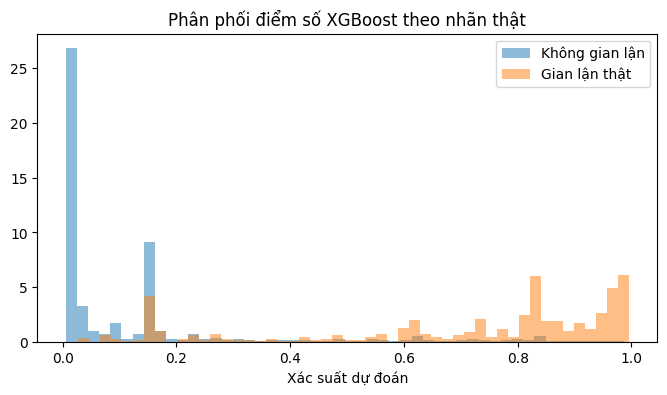

Tỷ lệ ca gian lận có score < 0.01: 0.0
Tỷ lệ ca gian lận có score < 0.05: 0.006357856494096276


In [31]:
import matplotlib.pyplot as plt

val_probs = xgb_model.predict_proba(X_val_xgb)[:, 1]

plt.figure(figsize=(8,4))
plt.hist(val_probs[y_val == 0], bins=50, alpha=0.5, label="Không gian lận", density=True)
plt.hist(val_probs[y_val == 1], bins=50, alpha=0.5, label="Gian lận thật", density=True)
plt.legend()
plt.xlabel("Xác suất dự đoán")
plt.title("Phân phối điểm số XGBoost theo nhãn thật")
plt.show()

print("Tỷ lệ ca gian lận có score < 0.01:", (val_probs[y_val==1] < 0.01).mean())
print("Tỷ lệ ca gian lận có score < 0.05:", (val_probs[y_val==1] < 0.05).mean())

### **SO SÁNH HIỆU SUẤT CỦA RU(RANDOM UNDERSAMPLING) VÀ SMOTE**

In [32]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek


def evaluate_resampling(sampler, name, X_train, y_train, X_val, y_val, X_test, y_test, params):
    """
    Resample TREN TAP TRAIN (val/test giu nguyen, khong duoc dung sampler),
    train 1 XGBoost voi params co dinh, chon threshold theo F1 tren VAL,
    roi danh gia tren TEST.
    """
    if sampler is not None:
        X_res, y_res = sampler.fit_resample(X_train, y_train)
    else:
        X_res, y_res = X_train, y_train

    model = XGBClassifier(**params)
    model.fit(X_res, y_res, eval_set=[(X_val, y_val)], verbose=0)

    val_probs = model.predict_proba(X_val)[:, 1]
    prec_v, rec_v, thresh_v = precision_recall_curve(y_val, val_probs)
    f1_v = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-12)
    best_idx = f1_v[:-1].argmax() if len(thresh_v) > 0 else 0
    best_threshold = thresh_v[best_idx] if len(thresh_v) > 0 else 0.5

    test_probs = model.predict_proba(X_test)[:, 1]
    test_pred = (test_probs >= best_threshold).astype(int)

    result = {
        "strategy": name,
        "n_train_class0": int((y_res == 0).sum()),
        "n_train_class1": int((y_res == 1).sum()),
        "threshold_from_val": round(float(best_threshold), 4),
        "test_AUCPR": average_precision_score(y_test, test_probs),
        "test_ROC_AUC": roc_auc_score(y_test, test_probs),
        "test_Precision": precision_score(y_test, test_pred, zero_division=0),
        "test_Recall": recall_score(y_test, test_pred, zero_division=0),
        "test_F1": f1_score(y_test, test_pred, zero_division=0),
    }
    return result, model


# Cac chien luoc muon so sanh - co the them/bot ty le tuy y
resampling_strategies = {
    "(a) Khong resample (baseline)":
        None,
    "(b) RandomUnderSampler (1:4)":
        RandomUnderSampler(sampling_strategy=1 / 4, random_state=RANDOM_STATE),
    "(c) SMOTE (1:4)":
        SMOTE(sampling_strategy=1 / 4, random_state=RANDOM_STATE, k_neighbors=5),
    "(d) SMOTE (1:2)":
        SMOTE(sampling_strategy=1 / 2, random_state=RANDOM_STATE, k_neighbors=5),
    "(e) SMOTE + Tomek-links (lam sach bien sau khi oversample)":
        SMOTETomek(sampling_strategy=1 / 4, random_state=RANDOM_STATE),
}

resample_results = []
resample_models = {}
for name, sampler in resampling_strategies.items():
    result, fitted_model = evaluate_resampling(
        sampler, name, X_train_xgb, y_train, X_val_xgb, y_val, X_test_xgb, y_test, final_params
    )
    resample_results.append(result)
    resample_models[name] = fitted_model
    print(f"Da xong: {name}")

resample_df = pd.DataFrame(resample_results).sort_values("test_AUCPR", ascending=False).reset_index(drop=True)
resample_df

Da xong: (a) Khong resample (baseline)
Da xong: (b) RandomUnderSampler (1:4)
Da xong: (c) SMOTE (1:4)
Da xong: (d) SMOTE (1:2)
Da xong: (e) SMOTE + Tomek-links (lam sach bien sau khi oversample)


,strategy,n_train_class0,n_train_class1,threshold_from_val,test_AUCPR,test_ROC_AUC,test_Precision,test_Recall,test_F1
0,(b) RandomUnderSampler (1:4),20952,5238,0.8495,0.550614,0.950967,0.751553,0.338936,0.467181
1,(c) SMOTE (1:4),164942,41235,0.7660,0.516854,0.946018,0.501157,0.404295,0.447545
2,(d) SMOTE (1:2),164942,82471,0.8241,0.509468,0.945538,0.436685,0.531279,0.479360
3,(e) SMOTE + Tomek-links (lam sach bien sau khi...,164907,41200,0.7263,0.503687,0.943969,0.456464,0.484594,0.470109
4,(a) Khong resample (baseline),164942,5238,0.3052,0.501525,0.946382,0.739229,0.304388,0.431217


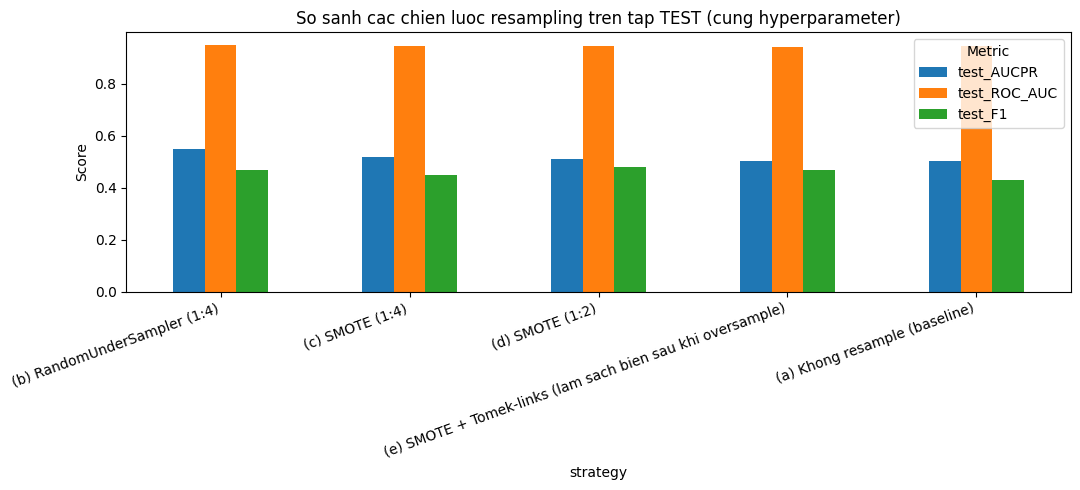


=== Chien luoc tot nhat theo AUCPR ===
strategy          (b) RandomUnderSampler (1:4)
test_AUCPR                            0.550614
test_ROC_AUC                          0.950967
test_Precision                        0.751553
test_Recall                           0.338936
test_F1                               0.467181
Name: 0, dtype: object

Luu y: ket qua nay dung CHUNG 1 bo hyperparameter (final_params, von da duoc Optuna tune rieng cho RandomUnderSampler o buoc truoc). De so sanh that su cong bang, nen tune lai Optuna (cell 31) rieng cho tung chien luoc resampling truoc khi ket luan chien luoc nao tot hon.


In [39]:
import matplotlib.pyplot as plt

metrics_to_plot = ["test_AUCPR", "test_ROC_AUC", "test_F1"]
plot_df = resample_df.set_index("strategy")[metrics_to_plot]

ax = plot_df.plot(kind="bar", figsize=(11, 5))
plt.title("So sanh cac chien luoc resampling tren tap TEST (cung hyperparameter)")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

print("\n=== Chien luoc tot nhat theo AUCPR ===")
best_row = resample_df.iloc[0]
print(best_row[["strategy", "test_AUCPR", "test_ROC_AUC", "test_Precision", "test_Recall", "test_F1"]])

print(
    "\nLuu y: ket qua nay dung CHUNG 1 bo hyperparameter (final_params, von da"
    " duoc Optuna tune rieng cho RandomUnderSampler o buoc truoc). De so sanh"
    " that su cong bang, nen tune lai Optuna (cell 31) rieng cho tung chien"
    " luoc resampling truoc khi ket luan chien luoc nao tot hon."
)

### **BẢNG SO SÁNH MỨC ĐỘ "ĐÓNG GÓP" CỦA TỪNG NHÓM ĐĂC TRƯNG**

In [35]:
VELOCITY_COLS = [c for c in [
    "time_since_last_txn_min", "time_since_previous_txn",
    "txn_count_1s", "txn_count_10s", "txn_count_60s", "txn_count_1h", "txn_count_2h",
    "amount_sum_1h", "amount_sum_2h",
    "unique_merchants_1h", "unique_countries_1h", "unique_cards_1h", "unique_cards_3h",
    "declined_unique_cards_1h", "approved_unique_cards_1h", "cards_reaching_limit_1h",
    "failed_txn_count_1m", "failed_txn_count_10m", "failed_txn_count_1h",
    "failed_txn_ratio_10m", "failed_txn_ratio_1h", "decline_streak", "decline_to_approval_ratio",
    "failed_ratio_recent",
    "amount_deviation_user_7d", "amount_deviation_user_30d", "amount_robust_zscore_user_30d",
    "amount_deviation_merchant", "amount_deviation_category", "amount_vs_previous_txn",
    "amount_time_angle",
    "channel_switch_rate",
    "geo_distance_km", "implied_travel_speed_kmh", "is_impossible_travel",
    "country_frequency", "city_frequency", "number_of_countries", "country_transaction_ratio",
    "country_changed", "is_new_country", "is_new_city",
    "hist_max_ratio", "hist_mean_ratio", "hist_mean_ratio_decay", "micro_txn_count_1h",
    "is_limit_testing_pattern", "is_card_testing_then_high_ticket",
    "is_midnight", "midnight_ratio_user_30d", "midnight_ratio_user_60d", "night_amount_deviation",
    "night_velocity_1h", "night_unique_merchants_1h", "night_country_novelty", "night_geo_velocity",
    "is_late_night_geo_velocity_anomaly",
] if c in train_enc.columns]

GRAPH_COLS = [c for c in [
] if c in train_enc.columns]

TABULAR_ONLY_COLS = [c for c in xgb_feature_cols if c not in VELOCITY_COLS + GRAPH_COLS + ["if_anomaly_score"]]

ablation_scenarios = {
    "(a) Tabular": TABULAR_ONLY_COLS,
    "(b) Tabular + Velocity": TABULAR_ONLY_COLS + VELOCITY_COLS,
    "(c) Tabular + Velocity + Graph": TABULAR_ONLY_COLS + VELOCITY_COLS + GRAPH_COLS,
    "(d) Tabular + Velocity + Graph + IF anomaly_score": xgb_feature_cols,
}

ablation_results = []
for name, cols in ablation_scenarios.items():
    m = XGBClassifier(**final_params)
    m.fit(train_enc[cols].fillna(0), y_train, eval_set=[(val_enc[cols].fillna(0), y_val)], verbose=0)
    probs = m.predict_proba(test_enc[cols].fillna(0))[:, 1]
    ablation_results.append({
        "scenario": name,
        "n_features": len(cols),
        "test_AUCPR": average_precision_score(y_test, probs),
        "test_ROC_AUC": roc_auc_score(y_test, probs),
    })

ablation_df = pd.DataFrame(ablation_results)
ablation_df


,scenario,n_features,test_AUCPR,test_ROC_AUC
0,(a) Tabular,45,0.255212,0.770049
1,(b) Tabular + Velocity,102,0.530839,0.952287
2,(c) Tabular + Velocity + Graph,102,0.530839,0.952287
3,(d) Tabular + Velocity + Graph + IF anomaly_score,103,0.501525,0.946382


### **SHAP**
Đây là thuật toán giải thích & tính toán mức độ đóng góp của từng đặc trung vào kết quả cuối cùng một cách công bằng và minh bách.

In [36]:
import shap

explainer = shap.TreeExplainer(xgb_model)      # model da fit tren X_train_xgb
shap_values = explainer.shap_values(X_test_xgb)

shap_df = pd.DataFrame(shap_values, columns=X_test_xgb.columns)

# Gop lai theo nhom phuong thuc: tabular / velocity / graph / anomaly
group_map = {
    "tabular": [c for c in X_test_xgb.columns if c.startswith((
        "Card_Type_", "Card_Network_", "Payment_Method_", "Transaction_Channel_",
        "Device_Type_", "Merchant_Risk_Level_", "Gender_", "Customer_Segment_",
        "Marital_Status_", "Occupation_", "Account_Type_", "Card_Mode_", "Hour_Bucket_",
        "Transaction_Amount", "Age", "Annual_Income", "Merchant_Rating",
        "account_age_days", "card_age_days", "merchant_age_days",
        "amount_to_credit_limit_ratio", "amount_to_available_credit_ratio",
    ))],
    "velocity": [c for c in X_test_xgb.columns if any(k in c for k in (
        "txn_count", "time_since_last_txn", "time_since_previous_txn",
        "amount_deviation", "amount_robust_zscore", "amount_vs_previous_txn", "amount_time_angle",
        "channel_switch_rate", "failed_", "decline_",
        "geo_distance", "implied_travel", "impossible_travel",
        "hist_max_ratio", "hist_mean_ratio", "micro_txn_count_1h",
        "limit_testing_pattern", "card_testing_then_high_ticket",
        "unique_merchants", "unique_countries", "unique_cards",
        "declined_unique_cards", "approved_unique_cards", "cards_reaching_limit",
        "country_", "city_frequency", "number_of_countries", "is_new_country", "is_new_city",
        "midnight", "night_",
    ))],
    "graph": [c for c in X_test_xgb.columns if any(k in c for k in (
        "degree", "pagerank", "clustering", "community", "high_risk_ratio", "graphsage_emb"
    ))],
    "anomaly": ["if_anomaly_score"],
}

print("=== Dong gop trung binh |SHAP| theo nhom phuong thuc ===")
for group, cols in group_map.items():
    cols = [c for c in cols if c in shap_df.columns]
    print(f"{group:10s} ({len(cols):3d} cot) — mean |SHAP|:", shap_df[cols].abs().sum(axis=1).mean())


=== Dong gop trung binh |SHAP| theo nhom phuong thuc ===
tabular    (  4 cot) — mean |SHAP|: 0.29714242
velocity   ( 55 cot) — mean |SHAP|: 2.0772262
graph      ( 32 cot) — mean |SHAP|: 0.49409756
anomaly    (  1 cot) — mean |SHAP|: 0.44921055


In [37]:
# Top 20 feature quan trong nhat theo mean |SHAP| (khong phan biet nhom)
top_features = shap_df.abs().mean().sort_values(ascending=False).head(20)
top_features


,0
amount_deviation_category,0.850029
if_anomaly_score,0.449226
declined_unique_cards_1h,0.367610
amount_deviation_merchant,0.354085
Transaction_Amount,0.294991
merchant_graphsage_emb_5,0.281365
failed_txn_count_1m,0.251050
Is_International,0.227092
failed_txn_count_10m,0.210195
merchant_graphsage_emb_14,0.111084


/tmp/ipykernel_561/886071752.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_xgb, max_display=20, show=True)


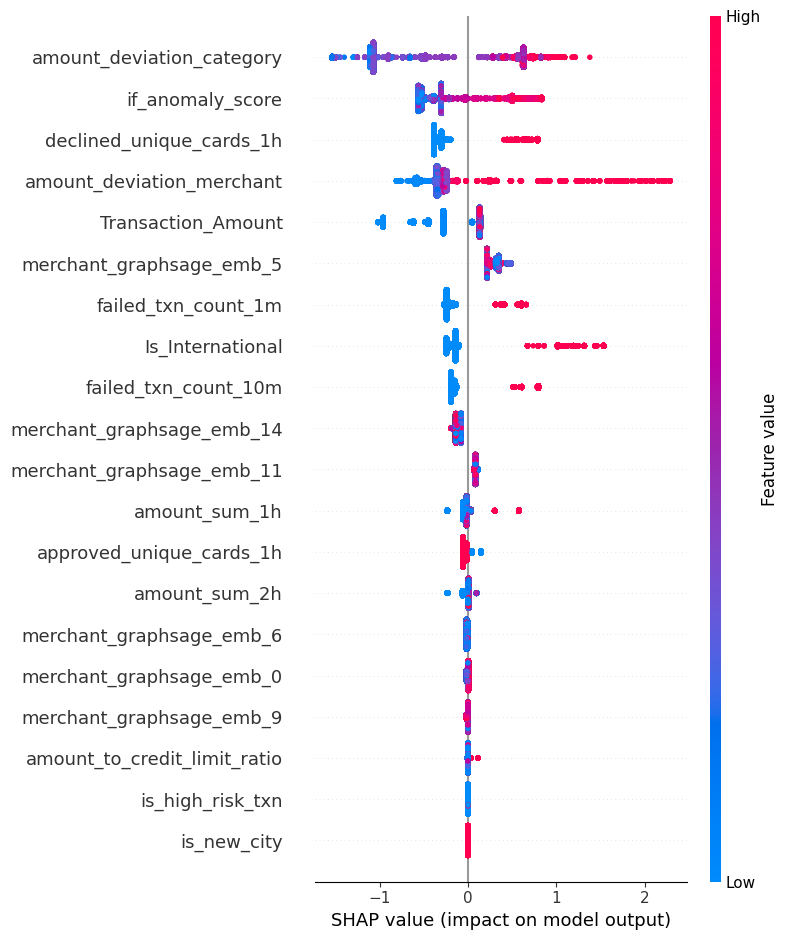

In [38]:
shap.summary_plot(shap_values, X_test_xgb, max_display=20, show=True)
